In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    precision_recall_curve, roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from lightgbm import LGBMClassifier
import joblib

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

print("OK")

OK


In [2]:
df = pd.read_parquet('../data/processed.parquet')
print(f"Размер: {df.shape}")
print(f"Диалогов: {df['dialogue_id'].nunique()}")
print(f"Доля is_end=1: {df['is_end'].mean():.3f}")
df.head()

Размер: (153983, 11)
Диалогов: 2000
Доля is_end=1: 0.088


,dialogue_id,turn_id,prefix_text,is_end,length_words,length_chars,last_word,ends_with_punct,has_question_word,last_pos,ends_with_prep
0,PMUL4398.json,0,i,0,1,1,i,0,0,PRON,0
1,PMUL4398.json,0,i need,0,2,6,need,0,0,VERB,0
2,PMUL4398.json,0,i need a,0,3,8,a,0,0,DET,0
3,PMUL4398.json,0,i need a place,0,4,14,place,0,0,NOUN,0
4,PMUL4398.json,0,i need a place to,0,5,17,to,0,0,PART,0


In [3]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(df, groups=df['dialogue_id']))

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print(f"Train: {len(train_df):,} строк, {train_df['dialogue_id'].nunique()} диалогов")
print(f"Test:  {len(test_df):,} строк, {test_df['dialogue_id'].nunique()} диалогов")
print()

# Проверка: нет пересечений по dialogue_id
overlap = set(train_df['dialogue_id']) & set(test_df['dialogue_id'])
print(f"Пересечение диалогов: {len(overlap)}  (должно быть 0)")

# Проверка: баланс классов сохраняется в обоих сплитах
print(f"\nДоля is_end=1 в train: {train_df['is_end'].mean():.3f}")
print(f"Доля is_end=1 в test:  {test_df['is_end'].mean():.3f}")

Train: 122,667 строк, 1600 диалогов
Test:  31,316 строк, 400 диалогов

Пересечение диалогов: 0  (должно быть 0)

Доля is_end=1 в train: 0.088
Доля is_end=1 в test:  0.087


In [4]:
# Числовые и бинарные признаки (берем как есть)
NUMERIC_FEATURES = ['length_words', 'length_chars', 'ends_with_punct', 
                    'ends_with_prep', 'has_question_word']

# Категориальные (нужен one-hot encoding)
CATEGORICAL_FEATURES = ['last_pos']

# last_word оставим на потом (там много уникальных значений, нужен target encoding)

# Целевая переменная
y_train = train_df['is_end'].values
y_test = test_df['is_end'].values

# Признаки
X_train_raw = train_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
X_test_raw = test_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]

print(f"X_train: {X_train_raw.shape}")
print(f"X_test:  {X_test_raw.shape}")
print(f"\nТипы признаков:")
print(X_train_raw.dtypes)
print(f"\nУникальные POS-теги: {X_train_raw['last_pos'].nunique()}")
print(X_train_raw['last_pos'].value_counts())


X_train: (122667, 6)
X_test:  (31316, 6)

Типы признаков:
length_words         int64
length_chars         int64
ends_with_punct      int64
ends_with_prep       int64
has_question_word    int64
last_pos               str
dtype: object

Уникальные POS-теги: 17
last_pos
NOUN     18731
PRON     16661
VERB     16270
DET      12248
ADP      11921
AUX      10277
PROPN     7077
INTJ      6390
ADJ       4765
ADV       4673
PART      4173
NUM       3952
SCONJ     2781
CCONJ     2541
X          105
PUNCT       92
SYM         10
Name: count, dtype: int64


In [5]:
# OneHotEncoder превращает категорию "ADP" в столбец где 1 если ADP, иначе 0
# handle_unknown='ignore' — если в тесте появится POS которого не было в train, не падать
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Обучаем на train, применяем на оба сплита
ohe.fit(X_train_raw[CATEGORICAL_FEATURES])

# Получаем имена новых столбцов
ohe_columns = ohe.get_feature_names_out(CATEGORICAL_FEATURES)
print(f"Создано {len(ohe_columns)} OHE-столбцов:")
print(list(ohe_columns))

# Применяем
X_train_ohe = pd.DataFrame(
    ohe.transform(X_train_raw[CATEGORICAL_FEATURES]),
    columns=ohe_columns,
    index=X_train_raw.index
)
X_test_ohe = pd.DataFrame(
    ohe.transform(X_test_raw[CATEGORICAL_FEATURES]),
    columns=ohe_columns,
    index=X_test_raw.index
)

# Собираем финальный X
X_train = pd.concat([X_train_raw[NUMERIC_FEATURES], X_train_ohe], axis=1)
X_test = pd.concat([X_test_raw[NUMERIC_FEATURES], X_test_ohe], axis=1)

print(f"\nИтоговая форма X_train: {X_train.shape}")
print(f"Столбцы: {list(X_train.columns)}")
X_train.head()

Создано 17 OHE-столбцов:
['last_pos_ADJ', 'last_pos_ADP', 'last_pos_ADV', 'last_pos_AUX', 'last_pos_CCONJ', 'last_pos_DET', 'last_pos_INTJ', 'last_pos_NOUN', 'last_pos_NUM', 'last_pos_PART', 'last_pos_PRON', 'last_pos_PROPN', 'last_pos_PUNCT', 'last_pos_SCONJ', 'last_pos_SYM', 'last_pos_VERB', 'last_pos_X']

Итоговая форма X_train: (122667, 22)
Столбцы: ['length_words', 'length_chars', 'ends_with_punct', 'ends_with_prep', 'has_question_word', 'last_pos_ADJ', 'last_pos_ADP', 'last_pos_ADV', 'last_pos_AUX', 'last_pos_CCONJ', 'last_pos_DET', 'last_pos_INTJ', 'last_pos_NOUN', 'last_pos_NUM', 'last_pos_PART', 'last_pos_PRON', 'last_pos_PROPN', 'last_pos_PUNCT', 'last_pos_SCONJ', 'last_pos_SYM', 'last_pos_VERB', 'last_pos_X']


,length_words,length_chars,ends_with_punct,ends_with_prep,has_question_word,last_pos_ADJ,last_pos_ADP,last_pos_ADV,last_pos_AUX,last_pos_CCONJ,last_pos_DET,last_pos_INTJ,last_pos_NOUN,last_pos_NUM,last_pos_PART,last_pos_PRON,last_pos_PROPN,last_pos_PUNCT,last_pos_SCONJ,last_pos_SYM,last_pos_VERB,last_pos_X
82,1,5,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
83,2,10,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
84,3,12,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
85,4,15,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
86,5,23,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [6]:
def evaluate_model(name, y_true, y_pred, y_proba=None):
    """Печатает метрики модели и возвращает dict с результатами."""
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else None
    
    print(f"\n=== {name} ===")
    print(f"F1-score:  {f1:.4f}")
    print(f"Precision: {precision:.4f}  (из названных 'конец' — доля реальных концов)")
    print(f"Recall:    {recall:.4f}  (из всех реальных концов — доля пойманных)")
    if auc is not None:
        print(f"ROC-AUC:   {auc:.4f}")
    
    print(f"\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=['не конец', 'конец']))
    
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion matrix:")
    print(f"                  Predicted")
    print(f"                  не конец  конец")
    print(f"Actual не конец    {cm[0,0]:>6}  {cm[0,1]:>6}")
    print(f"Actual конец       {cm[1,0]:>6}  {cm[1,1]:>6}")
    
    return {'name': name, 'f1': f1, 'precision': precision, 
            'recall': recall, 'auc': auc}


results = []  # будем накапливать результаты всех моделей
print("Готово")

Готово


Baseline — простое правило: если префикс заканчивается на .?!, считаем что это конец реплики. Это нижняя планка — любая ML-модель должна её обходить.

In [7]:
# Baseline (ends_with_punct)
y_pred_baseline = X_test['ends_with_punct'].values.astype(int)
baseline_result = evaluate_model('Baseline (ends_with_punct)', y_test, y_pred_baseline)
results.append(baseline_result)


=== Baseline (ends_with_punct) ===
F1-score:  0.7686
Precision: 0.6629  (из названных 'конец' — доля реальных концов)
Recall:    0.9142  (из всех реальных концов — доля пойманных)

Classification report:
              precision    recall  f1-score   support

    не конец       0.99      0.96      0.97     28599
       конец       0.66      0.91      0.77      2717

    accuracy                           0.95     31316
   macro avg       0.83      0.94      0.87     31316
weighted avg       0.96      0.95      0.96     31316

Confusion matrix:
                  Predicted
                  не конец  конец
Actual не конец     27336    1263
Actual конец          233    2484


In [8]:
# Logistic Regression

from sklearn.preprocessing import StandardScaler

# Стандартизация — LogReg чувствительна к масштабу признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# class_weight='balanced' — компенсация дисбаланса классов (87% vs 13%)
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)
lr.fit(X_train_scaled, y_train)

y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_proba_lr_train = lr.predict_proba(X_train_scaled)[:, 1]

print(f"LogReg обучилась за {lr.n_iter_[0]} итераций")

LogReg обучилась за 30 итераций


Стандартный порог 0.5 не оптимален при дисбалансе классов и class_weight='balanced'. Подбираем порог, максимизирующий F1, на train — иначе будет утечка данных в test.

Оптимальный порог по train: 0.83
F1 на train с этим порогом: 0.7853


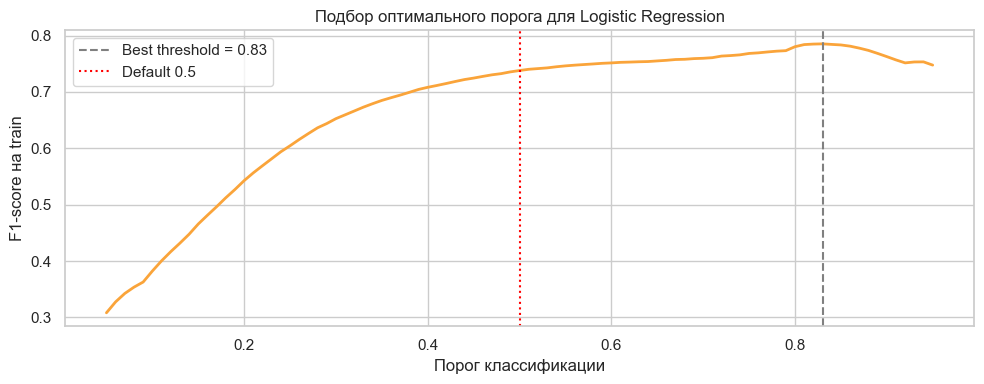

In [9]:
# Подбираем порог НА TRAIN (не на test — иначе утечка)
thresholds = np.linspace(0.05, 0.95, 91)
f1_by_threshold = [f1_score(y_train, (y_proba_lr_train > t).astype(int)) 
                   for t in thresholds]
best_threshold = thresholds[np.argmax(f1_by_threshold)]

print(f"Оптимальный порог по train: {best_threshold:.2f}")
print(f"F1 на train с этим порогом: {max(f1_by_threshold):.4f}")

# Визуализация: F1 как функция порога
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_by_threshold, color='#FAA43A', linewidth=2)
ax.axvline(best_threshold, color='gray', linestyle='--', 
           label=f'Best threshold = {best_threshold:.2f}')
ax.axvline(0.5, color='red', linestyle=':', label='Default 0.5')
ax.set_xlabel('Порог классификации')
ax.set_ylabel('F1-score на train')
ax.set_title('Подбор оптимального порога для Logistic Regression')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/logreg_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
y_pred_lr = (y_proba_lr > best_threshold).astype(int)
lr_result = evaluate_model(
    f'Logistic Regression (threshold={best_threshold:.2f})',
    y_test, y_pred_lr, y_proba_lr
)
results.append(lr_result)


=== Logistic Regression (threshold=0.83) ===
F1-score:  0.7918
Precision: 0.7165  (из названных 'конец' — доля реальных концов)
Recall:    0.8848  (из всех реальных концов — доля пойманных)
ROC-AUC:   0.9726

Classification report:
              precision    recall  f1-score   support

    не конец       0.99      0.97      0.98     28599
       конец       0.72      0.88      0.79      2717

    accuracy                           0.96     31316
   macro avg       0.85      0.93      0.88     31316
weighted avg       0.97      0.96      0.96     31316

Confusion matrix:
                  Predicted
                  не конец  конец
Actual не конец     27648     951
Actual конец          313    2404


=== Топ-15 признаков по абсолютной величине коэффициента ===
        feature  coefficient
ends_with_punct     1.550040
   length_chars     0.885074
 last_pos_CCONJ    -0.547043
  last_pos_NOUN     0.475292
 last_pos_SCONJ    -0.378607
   last_pos_AUX    -0.359771
  last_pos_INTJ     0.331382
 last_pos_PROPN     0.325076
   last_pos_NUM     0.322958
  last_pos_PART    -0.268175
   length_words    -0.228936
   last_pos_ADP    -0.227367
 ends_with_prep    -0.227367
   last_pos_DET    -0.212947
  last_pos_VERB     0.069455


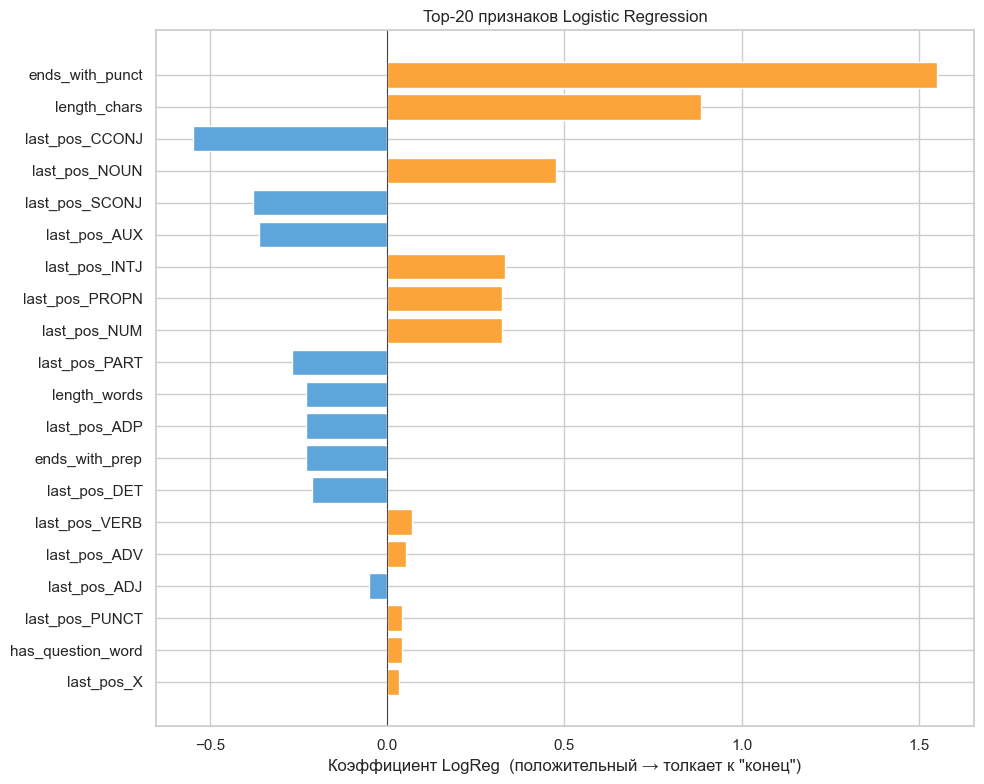

In [11]:
feature_importance_lr = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("=== Топ-15 признаков по абсолютной величине коэффициента ===")
print(feature_importance_lr.head(15).to_string(index=False))

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))
top = feature_importance_lr.head(20)
colors = ['#FAA43A' if c > 0 else '#5DA5DA' for c in top['coefficient']]
ax.barh(top['feature'], top['coefficient'], color=colors)
ax.set_xlabel('Коэффициент LogReg  (положительный → толкает к "конец")')
ax.set_title('Top-20 признаков Logistic Regression')
ax.axvline(0, color='black', linewidth=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/logreg_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

Положительные коэффициенты толкают к классу «конец», отрицательные — к «не конец». Картинка должна совпадать с выводами EDA: punct/length/NOUN/INTJ тянут к концу, ADP/DET/CCONJ тянут к середине.

In [12]:
results_df = pd.DataFrame(results)
print("=== Промежуточное сравнение моделей ===")
print(results_df.to_string(index=False))

=== Промежуточное сравнение моделей ===
                                name       f1  precision   recall      auc
          Baseline (ends_with_punct) 0.768564   0.662930 0.914244      NaN
Logistic Regression (threshold=0.83) 0.791831   0.716542 0.884799 0.972646


In [13]:
# LightGBM НЕ нужна стандартизация (он работает с порогами, а не с весами)
# is_unbalance=True — компенсация дисбаланса классов

lgbm = LGBMClassifier(
    n_estimators=500,        # количество деревьев
    learning_rate=0.05,      # темп обучения
    num_leaves=31,           # сложность каждого дерева
    is_unbalance=True,       # балансировка классов
    random_state=RANDOM_STATE,
    n_jobs=-1,               # использовать все ядра
    verbose=-1,              # не печатать тонны логов
)

lgbm.fit(X_train, y_train)

y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]
y_proba_lgbm_train = lgbm.predict_proba(X_train)[:, 1]

print(f"Обучено деревьев: {lgbm.n_estimators_}")
print(f"Признаков: {lgbm.n_features_}")

Обучено деревьев: 500
Признаков: 22


In [14]:
f1_by_threshold = [f1_score(y_train, (y_proba_lgbm_train > t).astype(int)) 
                   for t in thresholds]
best_threshold_lgbm = thresholds[np.argmax(f1_by_threshold)]

print(f"Оптимальный порог LightGBM: {best_threshold_lgbm:.2f}")
print(f"F1 на train с этим порогом: {max(f1_by_threshold):.4f}")

y_pred_lgbm = (y_proba_lgbm > best_threshold_lgbm).astype(int)
lgbm_result = evaluate_model(
    f'LightGBM (threshold={best_threshold_lgbm:.2f})',
    y_test, y_pred_lgbm, y_proba_lgbm
)
results.append(lgbm_result)

Оптимальный порог LightGBM: 0.88
F1 на train с этим порогом: 0.8216

=== LightGBM (threshold=0.88) ===
F1-score:  0.8243
Precision: 0.7729  (из названных 'конец' — доля реальных концов)
Recall:    0.8830  (из всех реальных концов — доля пойманных)
ROC-AUC:   0.9786

Classification report:
              precision    recall  f1-score   support

    не конец       0.99      0.98      0.98     28599
       конец       0.77      0.88      0.82      2717

    accuracy                           0.97     31316
   macro avg       0.88      0.93      0.90     31316
weighted avg       0.97      0.97      0.97     31316

Confusion matrix:
                  Predicted
                  не конец  конец
Actual не конец     27894     705
Actual конец          318    2399


=== Top-15 важных признаков LightGBM ===
          feature   importance
  ends_with_punct 1.695149e+06
     length_chars 1.745821e+05
     length_words 5.095232e+04
    last_pos_NOUN 4.018642e+04
   last_pos_PROPN 2.494555e+04
     last_pos_NUM 2.347911e+04
    last_pos_INTJ 2.167964e+04
   ends_with_prep 1.722384e+04
has_question_word 1.005687e+04
     last_pos_DET 9.143451e+03
    last_pos_VERB 8.073284e+03
    last_pos_PRON 7.666660e+03
     last_pos_AUX 6.474426e+03
     last_pos_ADJ 4.964010e+03
    last_pos_PART 4.869949e+03


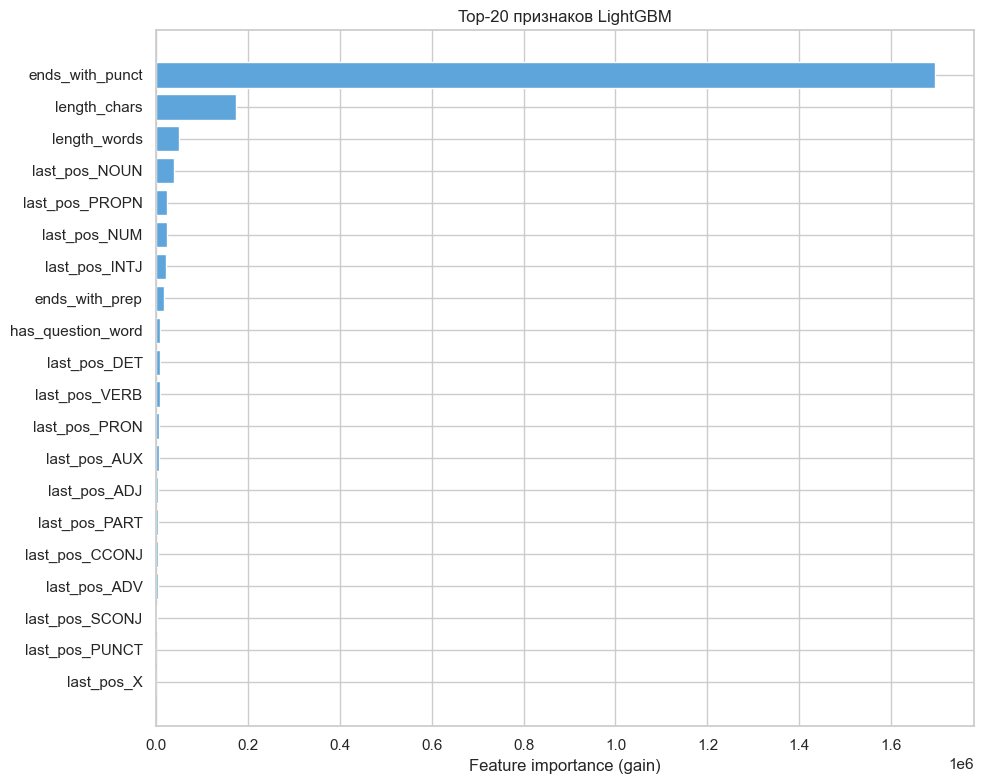

In [15]:
feature_importance_lgbm = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgbm.booster_.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print("=== Top-15 важных признаков LightGBM ===")
print(feature_importance_lgbm.head(15).to_string(index=False))

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))
top = feature_importance_lgbm.head(20)
ax.barh(top['feature'], top['importance'], color='#5DA5DA')
ax.set_xlabel('Feature importance (gain)')
ax.set_title('Top-20 признаков LightGBM')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/lgbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
from sklearn.model_selection import GroupKFold

# Группируем по dialogue_id — те же диалоги не должны попасть в разные fold'ы
groups_train = train_df['dialogue_id'].values

# 3 fold'а достаточно для скорости. На реальных проектах берут 5.
gkf = GroupKFold(n_splits=3)
print(f"Train: {len(X_train):,} строк, {pd.Series(groups_train).nunique()} диалогов")
print(f"Будет {gkf.n_splits} fold'ов для cross-validation")

Train: 122,667 строк, 1600 диалогов
Будет 3 fold'ов для cross-validation


In [17]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # меньше шума

def objective(trial):
    """Один запуск с пробным набором параметров. Возвращает F1 на CV."""
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 800),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 15, 127),
        'max_depth':        trial.suggest_int('max_depth', 3, 12),
        'min_child_samples':trial.suggest_int('min_child_samples', 10, 100),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'is_unbalance':     True,
        'random_state':     RANDOM_STATE,
        'n_jobs':           -1,
        'verbose':          -1,
    }
    
    f1_scores = []
    for fold_idx, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups_train)):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]
        
        model = LGBMClassifier(**params)
        model.fit(X_tr, y_tr)
        
        # Подбираем порог отдельно для каждого fold'а
        proba_val = model.predict_proba(X_val)[:, 1]
        proba_tr = model.predict_proba(X_tr)[:, 1]
        
        # Порог по train этого fold'а
        thr = thresholds[np.argmax([f1_score(y_tr, (proba_tr > t).astype(int)) 
                                    for t in thresholds])]
        pred_val = (proba_val > thr).astype(int)
        f1_scores.append(f1_score(y_val, pred_val))
    
    return np.mean(f1_scores)


# Запуск оптимизации
print("Запускаю Optuna (30 попыток)...")
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nЛучший F1 (среднее по CV): {study.best_value:.4f}")
print(f"Лучшие параметры:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Запускаю Optuna (30 попыток)...


  0%|          | 0/30 [00:00<?, ?it/s]


Лучший F1 (среднее по CV): 0.8157
Лучшие параметры:
  n_estimators: 564
  learning_rate: 0.02544166090938368
  num_leaves: 73
  max_depth: 8
  min_child_samples: 26
  subsample: 0.9878338511058234
  colsample_bytree: 0.9100531293444458
  reg_alpha: 5.727904470799623
  reg_lambda: 3.7958531426706403


In [18]:
# Берём лучшие параметры и обучаем на ВСЕМ train
best_params = study.best_params.copy()
best_params.update({
    'is_unbalance': True,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbose': -1,
})

lgbm_tuned = LGBMClassifier(**best_params)
lgbm_tuned.fit(X_train, y_train)

# Проба и подбор порога на train
y_proba_tuned = lgbm_tuned.predict_proba(X_test)[:, 1]
y_proba_tuned_train = lgbm_tuned.predict_proba(X_train)[:, 1]

f1_train_by_thr = [f1_score(y_train, (y_proba_tuned_train > t).astype(int)) 
                   for t in thresholds]
best_threshold_tuned = thresholds[np.argmax(f1_train_by_thr)]

y_pred_tuned = (y_proba_tuned > best_threshold_tuned).astype(int)
lgbm_tuned_result = evaluate_model(
    f'LightGBM tuned (threshold={best_threshold_tuned:.2f})',
    y_test, y_pred_tuned, y_proba_tuned
)
results.append(lgbm_tuned_result)


=== LightGBM tuned (threshold=0.87) ===
F1-score:  0.8267
Precision: 0.7722  (из названных 'конец' — доля реальных концов)
Recall:    0.8896  (из всех реальных концов — доля пойманных)
ROC-AUC:   0.9791

Classification report:
              precision    recall  f1-score   support

    не конец       0.99      0.98      0.98     28599
       конец       0.77      0.89      0.83      2717

    accuracy                           0.97     31316
   macro avg       0.88      0.93      0.90     31316
weighted avg       0.97      0.97      0.97     31316

Confusion matrix:
                  Predicted
                  не конец  конец
Actual не конец     27886     713
Actual конец          300    2417


=== Финальное сравнение моделей ===
                                name       f1  precision   recall      auc
     LightGBM tuned (threshold=0.87) 0.826749   0.772204 0.889584 0.979074
           LightGBM (threshold=0.88) 0.824257   0.772874 0.882959 0.978552
Logistic Regression (threshold=0.83) 0.791831   0.716542 0.884799 0.972646
          Baseline (ends_with_punct) 0.768564   0.662930 0.914244      NaN


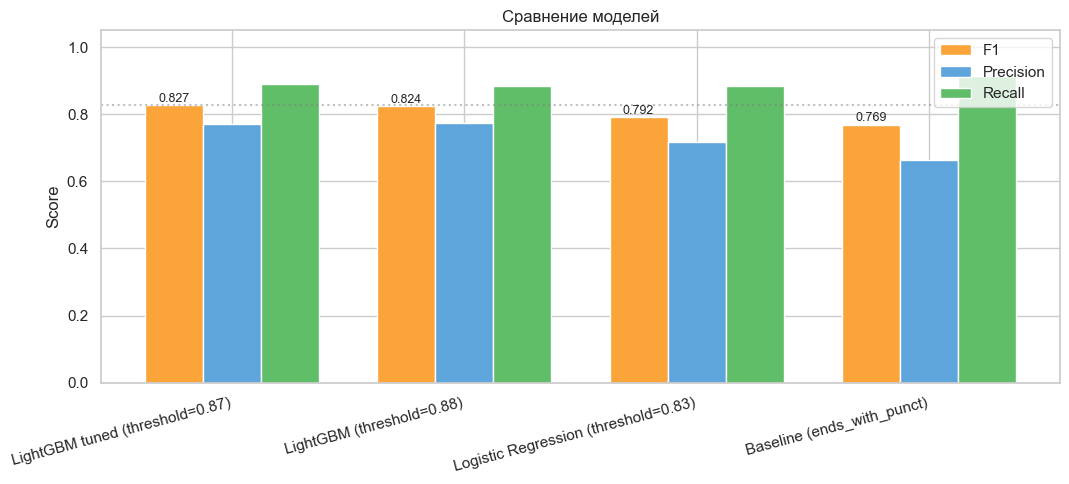

In [19]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('f1', ascending=False).reset_index(drop=True)

print("=== Финальное сравнение моделей ===")
print(results_df.to_string(index=False))

# Визуализация
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(results_df))
width = 0.25

ax.bar(x - width, results_df['f1'], width, label='F1', color='#FAA43A')
ax.bar(x, results_df['precision'], width, label='Precision', color='#5DA5DA')
ax.bar(x + width, results_df['recall'], width, label='Recall', color='#60BD68')

ax.set_xticks(x)
ax.set_xticklabels(results_df['name'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Сравнение моделей')
ax.set_ylim(0, 1.05)
ax.legend()
ax.axhline(results_df['f1'].max(), color='gray', linestyle=':', alpha=0.5)

# Подписи F1 над барами
for i, f1 in enumerate(results_df['f1']):
    ax.text(i - width, f1 + 0.01, f'{f1:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

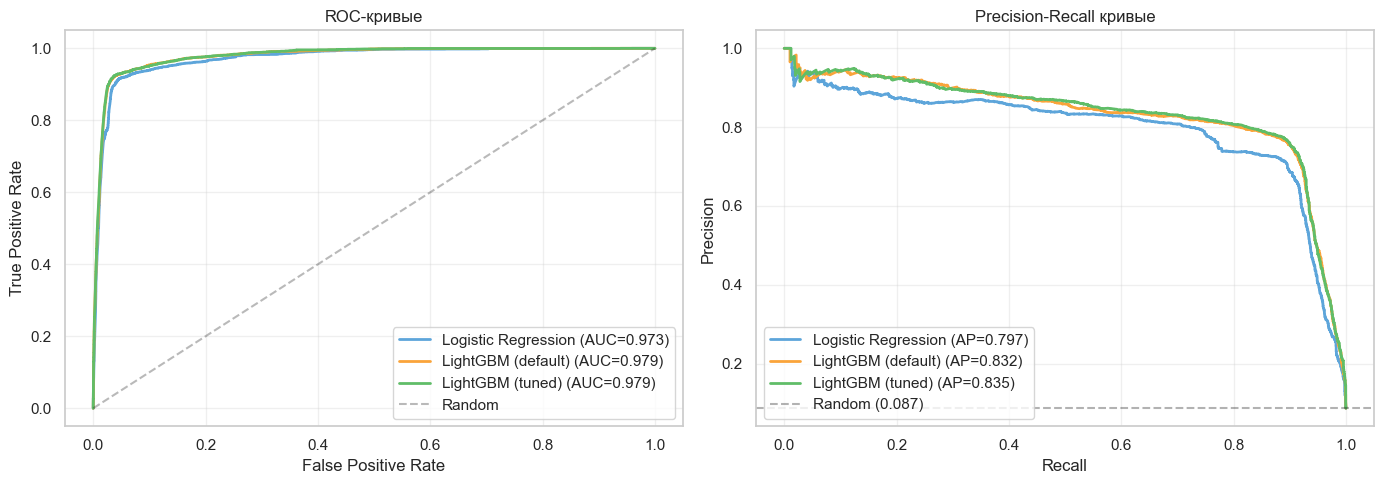

In [20]:
from sklearn.metrics import roc_curve, auc as sk_auc, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Модели с вероятностями (baseline не имеет — пропустим)
models_with_proba = [
    ('Logistic Regression', y_proba_lr, '#5DA5DA'),
    ('LightGBM (default)', y_proba_lgbm, '#FAA43A'),
    ('LightGBM (tuned)', y_proba_tuned, '#60BD68'),
]

# ROC curves
for name, proba, color in models_with_proba:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = sk_auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, 
                 label=f'{name} (AUC={roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC-кривые')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Precision-Recall curves
for name, proba, color in models_with_proba:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, color=color, linewidth=2, 
                 label=f'{name} (AP={ap:.3f})')

# Baseline для PR — горизонтальная линия на уровне доли положительного класса
axes[1].axhline(y_test.mean(), color='black', linestyle='--', alpha=0.3, 
                label=f'Random ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall кривые')
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

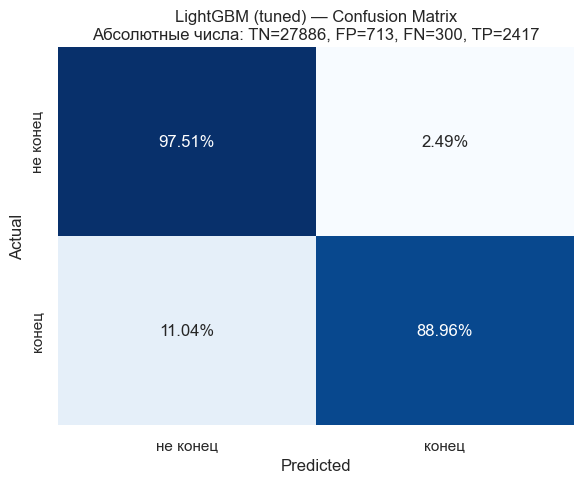


=== Ошибки финальной модели ===
False Positives (бот перебил): 713 (2.3% от теста)
False Negatives (бот тупил):   300 (1.0% от теста)


In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_tuned)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['не конец', 'конец'],
            yticklabels=['не конец', 'конец'],
            cbar=False, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'LightGBM (tuned) — Confusion Matrix\nАбсолютные числа: TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}')
plt.tight_layout()
plt.savefig('../reports/figures/final_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Ошибки финальной модели ===")
print(f"False Positives (бот перебил): {cm[0,1]:,} ({cm[0,1]/cm.sum()*100:.1f}% от теста)")
print(f"False Negatives (бот тупил):   {cm[1,0]:,} ({cm[1,0]/cm.sum()*100:.1f}% от теста)")

In [22]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Сохраняем модель + всё нужное для инференса
artifacts = {
    'model': lgbm_tuned,
    'ohe': ohe,
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'threshold': best_threshold_tuned,
    'feature_columns': list(X_train.columns),
}

joblib.dump(artifacts, '../models/turn_detector.pkl')

# Проверка
loaded = joblib.load('../models/turn_detector.pkl')
print(f"Сохранено: models/turn_detector.pkl")
print(f"Размер модели: {os.path.getsize('../models/turn_detector.pkl') / 1024:.1f} KB")
print(f"\nСохранённые артефакты:")
for k in loaded:
    print(f"  - {k}: {type(loaded[k]).__name__}")

Сохранено: models/turn_detector.pkl
Размер модели: 2883.5 KB

Сохранённые артефакты:
  - model: LGBMClassifier
  - ohe: OneHotEncoder
  - numeric_features: list
  - categorical_features: list
  - threshold: float64
  - feature_columns: list
